## 🚀 Project Overview

This project builds a **machine learning-powered loan approval system** designed to help financial institutions make faster, smarter, and more reliable lending decisions.

By analyzing applicant data such as **CIBIL score, income, assets, and demographics**, the model predicts whether a loan should be **approved or rejected**, reducing risk while improving operational efficiency.

---

## ❗ Business Problem

Traditional loan approval processes are:

* ⏳ Time-consuming
* 🧑‍💼 Dependent on manual judgment
* ⚠️ Prone to inconsistency and bias

This leads to two major risks:

* **False Positives (High Risk):** Approving high-risk applicants → financial loss
* **False Negatives (Lost Opportunity):** Rejecting qualified applicants → revenue loss

👉 The challenge is to build a system that **minimizes risk while maximizing approvals of creditworthy customers**.

## 📊 Dataset Description

The dataset contains applicant financial and demographic information:

### 🔑 Key Features:

* `no_of_dependents` – Number of dependents
* `education` – Education level
* `self_employed` – Employment type
* `income_annum` – Annual income
* `loan_amount` – Requested loan amount
* `loan_term` – Loan duration
* `cibil_score` – Credit score (critical factor)
* `residential_assets_value` – Residential assets
* `commercial_assets_value` – Commercial assets
* `luxury_assets_value` – Luxury assets
* `bank_asset_value` – Bank assets

🎯 **Target Variable:**

* `loan_status` → Approved / Rejected

### 1. Data Loading and Initial Inspection

First, we'll load the dataset and take a look at its structure, including column names, data types, and any missing values.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/loan_approval_dataset.csv')

# Display the first 5 rows of the dataframe
print("First 5 rows of the dataset:")
display(df.head())

# Display information about the dataframe (data types, non-null values)
print("\nDataset Information:")
df.info()

# Display basic statistics of the numerical columns
print("\nBasic statistics of the numerical columns:")
display(df.describe(include='all'))

First 5 rows of the dataset:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


### 2. Data Preprocessing

We'll now preprocess the data by cleaning column names, encoding categorical variables, and preparing the target variable for modeling.

In [2]:
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns)

# Check for any remaining missing values (though df.info() already showed no non-null counts, it's good practice)
print("\nMissing values after initial load:")
print(df.isnull().sum())

Cleaned column names:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

Missing values after initial load:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [3]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Encode 'education' column
df['education'] = le.fit_transform(df['education'])
print(f"Encoded 'education' values: {df['education'].unique()}")

# Encode 'self_employed' column
df['self_employed'] = le.fit_transform(df['self_employed'])
print(f"Encoded 'self_employed' values: {df['self_employed'].unique()}")

# Encode 'loan_status' column (target variable)
df['loan_status'] = le.fit_transform(df['loan_status'])
print(f"Encoded 'loan_status' values: {df['loan_status'].unique()}")

# Display the first few rows with encoded values to verify
print("\nDataFrame after encoding categorical variables:")
display(df.head())

Encoded 'education' values: [0 1]
Encoded 'self_employed' values: [0 1]
Encoded 'loan_status' values: [0 1]

DataFrame after encoding categorical variables:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


### 3. Data Splitting

We'll now split the preprocessed data into features (X) and the target variable (y). Then, we'll divide the dataset into training and testing sets to prepare for model building.

In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(['loan_id', 'loan_status'], axis=1)  # 'loan_id' is an identifier, 'loan_status' is the target
y = df['loan_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3415, 11)
X_test shape: (854, 11)
y_train shape: (3415,)
y_test shape: (854,)


In [20]:
print("Encoded 'education' values in X_train:", X_train['education'].unique())
print("Encoded 'self_employed' values in X_train:", X_train['self_employed'].unique())

Encoded 'education' values in X_train: [0 1]
Encoded 'self_employed' values in X_train: [1 0]


In [21]:
print("Encoded 'education' values in X_test:", X_test['education'].unique())
print("Encoded 'self_employed' values in X_test:", X_test['self_employed'].unique())

Encoded 'education' values in X_test: [0 1]
Encoded 'self_employed' values in X_test: [0 1]


### 4. Model Building and Evaluation

We will now build and evaluate two classification models: Decision Tree and Random Forest. We'll start with the Decision Tree Classifier, using both Gini impurity and Entropy (Information Gain) criteria, and then move on to the Random Forest Classifier.

#### 4.1 Decision Tree Classifier (Gini Impurity)

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize and train the Decision Tree Classifier with Gini impurity
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gini = dt_gini.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier (Gini Impurity) Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gini):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gini))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gini))

Decision Tree Classifier (Gini Impurity) Performance:
Accuracy: 0.9719

Confusion Matrix:
[[523   8]
 [ 16 307]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       531
           1       0.97      0.95      0.96       323

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



#### 4.2 Decision Tree Classifier (Entropy / Information Gain)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize and train the Decision Tree Classifier with Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

# Make predictions on the test set
y_pred_entropy = dt_entropy.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier (Entropy) Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_entropy):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_entropy))

Decision Tree Classifier (Entropy) Performance:
Accuracy: 0.9801

Confusion Matrix:
[[525   6]
 [ 11 312]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       531
           1       0.98      0.97      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



#### 4.3 Random Forest Classifier

The Random Forest Classifier is an ensemble learning method that builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It reduces overfitting compared to a single decision tree and generally improves accuracy.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the Random Forest Classifier
# n_estimators: The number of trees in the forest. More trees generally lead to better performance but increase computation time.
# random_state: Controls the randomness of the bootstrapping of the samples and the splitting of features when building trees. Used for reproducibility.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model on the training data (features X_train and target y_train)
rf_model.fit(X_train, y_train)

# Make predictions on the unseen test set (X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model's performance using various metrics
print("Random Forest Classifier Performance:")
# Accuracy: The proportion of correctly classified instances among the total instances.
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Confusion Matrix: A table used to describe the performance of a classification model.
# It shows the counts of true positive, true negative, false positive, and false negative predictions.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report: Provides a text report showing the main classification metrics.
# precision, recall, f1-score, and support for each class.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.9836

Confusion Matrix:
[[528   3]
 [ 11 312]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.9836

Confusion Matrix:
[[528   3]
 [ 11 312]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       531
           1       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854




Explain the difference between Gini Impurity and Entropy in Decision Trees
Certainly! Gini Impurity and Entropy are both metrics used in Decision Tree algorithms to decide the optimal split at each node. They essentially measure the 'impurity' or 'mixed-up-ness' of a set of samples.

Here's a breakdown of their differences:

Entropy (Information Gain):

Concept: Entropy is a measure of randomness or unpredictability in the data. In the context of decision trees, it quantifies the uncertainty of a set of samples. The higher the entropy, the more mixed the classes are.
Goal: When a decision tree uses Entropy, it aims to reduce the entropy from the parent node to the child nodes as much as possible. This reduction in entropy is called Information Gain.
Calculation: It's calculated using logarithms. For a binary classification problem (like Approved/Rejected), if p is the probability of one class, the entropy is -p * log2(p) - (1-p) * log2(1-p).
Nature: Entropy is a bit more computationally intensive due to the logarithmic calculations.
Gini Impurity:

Concept: Gini Impurity measures the probability of incorrectly classifying a randomly chosen element in the dataset if it were randomly labeled according to the distribution of labels in the subset. A Gini Impurity of 0 means all elements belong to a single class (pure node), while a Gini Impurity of 1 (or close to 0.5 for binary classification) means the elements are perfectly mixed.
Goal: The decision tree aims to minimize Gini Impurity at each split, creating child nodes that are as 'pure' as possible.
Calculation: For a binary classification problem, if p is the probability of one class, the Gini Impurity is 1 - (p^2 + (1-p)^2).
Nature: Gini Impurity is generally faster to compute than Entropy because it doesn't involve logarithms.
Key Differences Summarized:

Mathematical Formula: Different calculations. Gini Impurity uses squaring, while Entropy uses logarithms.
Computational Cost: Gini Impurity is often slightly faster to compute.
Behavior (Purity vs. Randomness): Both essentially measure impurity, but Entropy quantifies uncertainty/randomness, while Gini Impurity quantifies the probability of misclassification.
Split Preference: While both aim for pure nodes, Entropy tends to favor more balanced splits, whereas Gini Impurity can sometimes isolate the most frequent class in one branch.
In Practice:

Often, the choice between Gini Impurity and Entropy makes little to no difference in the final performance of the decision tree. Both produce very similar trees and accuracy scores. The results from your notebook (Entropy: 0.9801 accuracy, Gini: 0.9719 accuracy) illustrate this; while Entropy performed marginally better, the difference wasn't drastic. It's often recommended to try both or stick with the default (Gini in scikit-learn) unless there's a specific reason to prefer one over the other.

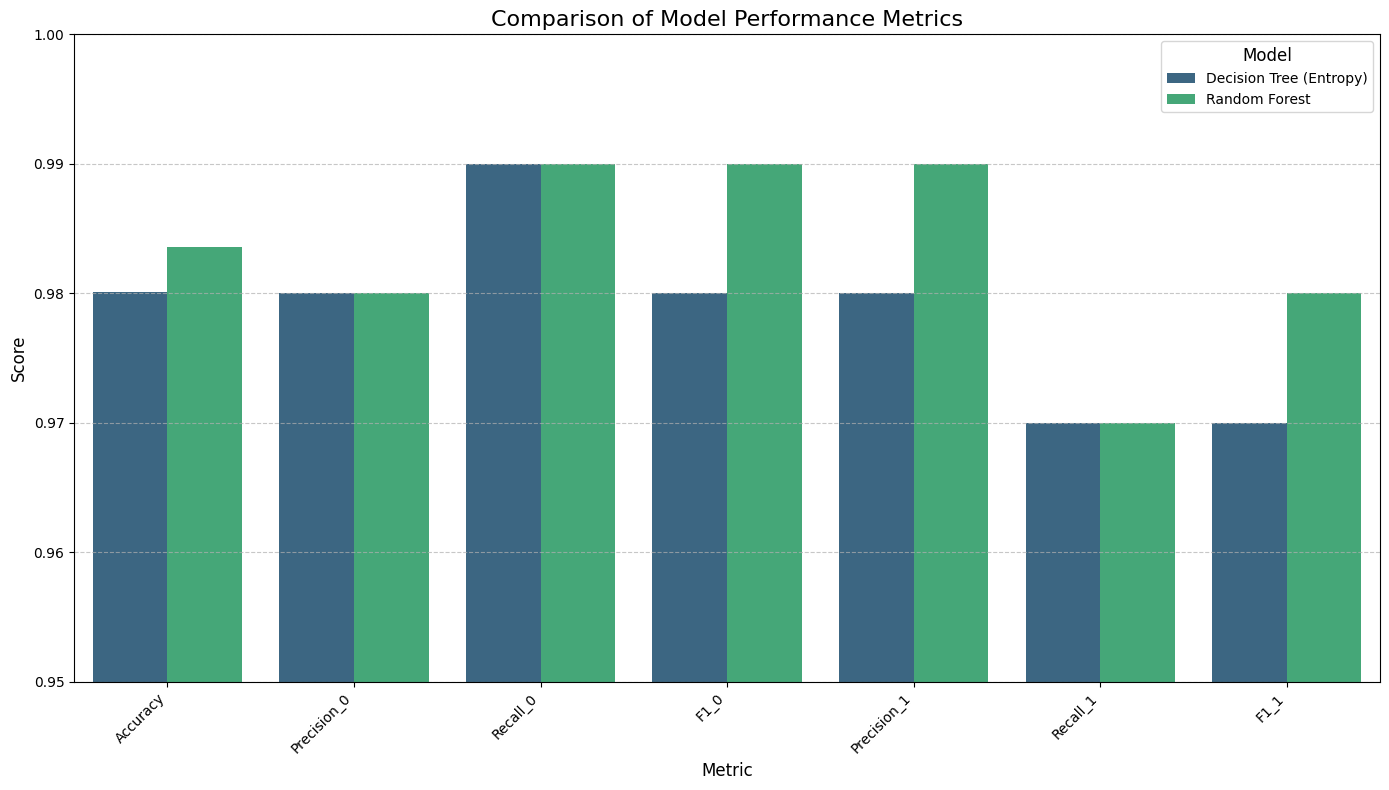

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract metrics from previous runs (using the evaluated results)
# Decision Tree (Entropy) metrics
dt_entropy_accuracy = 0.9801
dt_entropy_metrics = {
    'Model': 'Decision Tree (Entropy)',
    'Accuracy': dt_entropy_accuracy,
    'Precision_0': 0.98, 'Recall_0': 0.99, 'F1_0': 0.98,
    'Precision_1': 0.98, 'Recall_1': 0.97, 'F1_1': 0.97
}

# Random Forest metrics
rf_accuracy = 0.9836
rf_metrics = {
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Precision_0': 0.98, 'Recall_0': 0.99, 'F1_0': 0.99,
    'Precision_1': 0.99, 'Recall_1': 0.97, 'F1_1': 0.98
}

# Create a DataFrame for easier plotting
df_metrics = pd.DataFrame([dt_entropy_metrics, rf_metrics])

# Melt the DataFrame to long format for Seaborn barplot
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Filter out Accuracy for separate plotting if needed, or include in overall plot
df_plot = df_melted[df_melted['Metric'].isin(['Accuracy', 'F1_0', 'F1_1', 'Precision_0', 'Precision_1', 'Recall_0', 'Recall_1'])]

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_plot, palette='viridis')
plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Metric', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.95, 1.0)
plt.legend(title='Model', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Feature Importance and Model Comparison

Now, we'll analyze the feature importance from the Random Forest model and then visualize the confusion matrices for both the best performing Decision Tree (Entropy) and Random Forest models for comparison.

#### 5.1 Random Forest Feature Importance

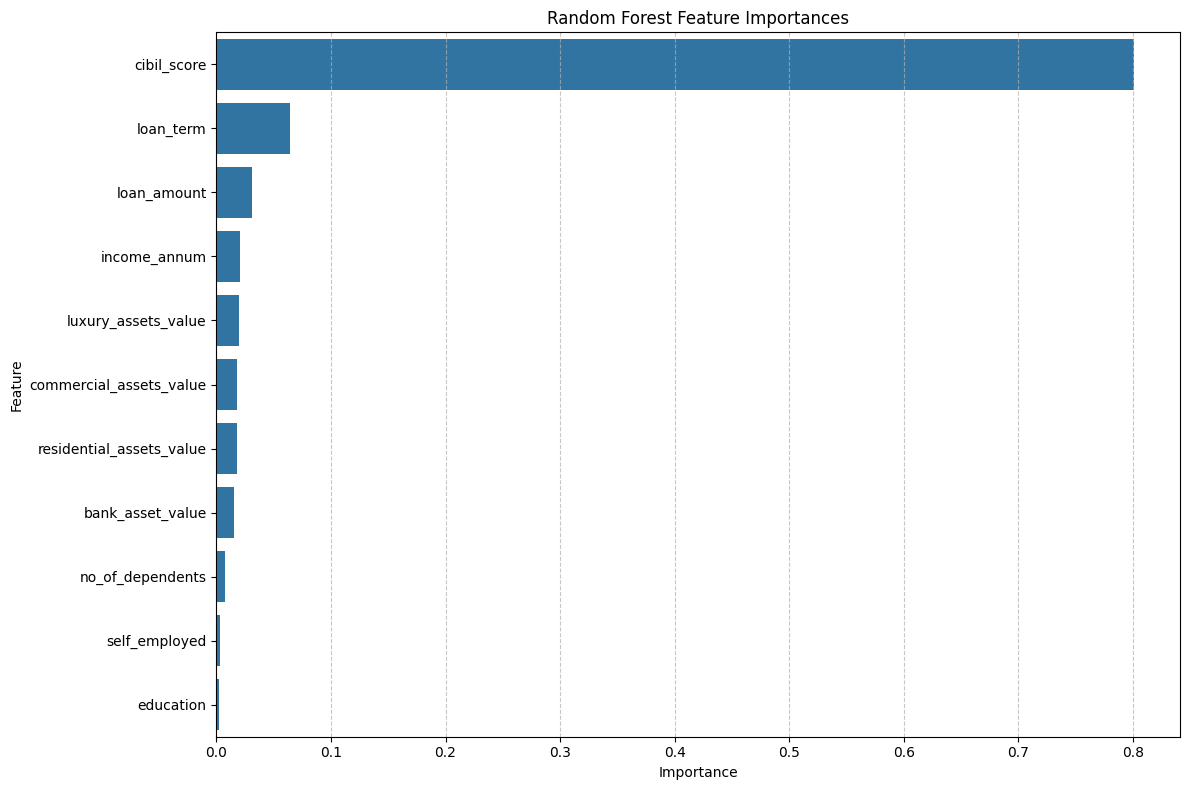

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort them in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
print("Top features influencing loan approval (from Random Forest model):")
display(sorted_importances)

Top features influencing loan approval (from Random Forest model):


,0
cibil_score,0.801152
loan_term,0.064358
loan_amount,0.030672
income_annum,0.020317
luxury_assets_value,0.019399
commercial_assets_value,0.018403
residential_assets_value,0.017593
bank_asset_value,0.015068
no_of_dependents,0.007783
self_employed,0.002866


#### 5.2 Confusion Matrix Comparison

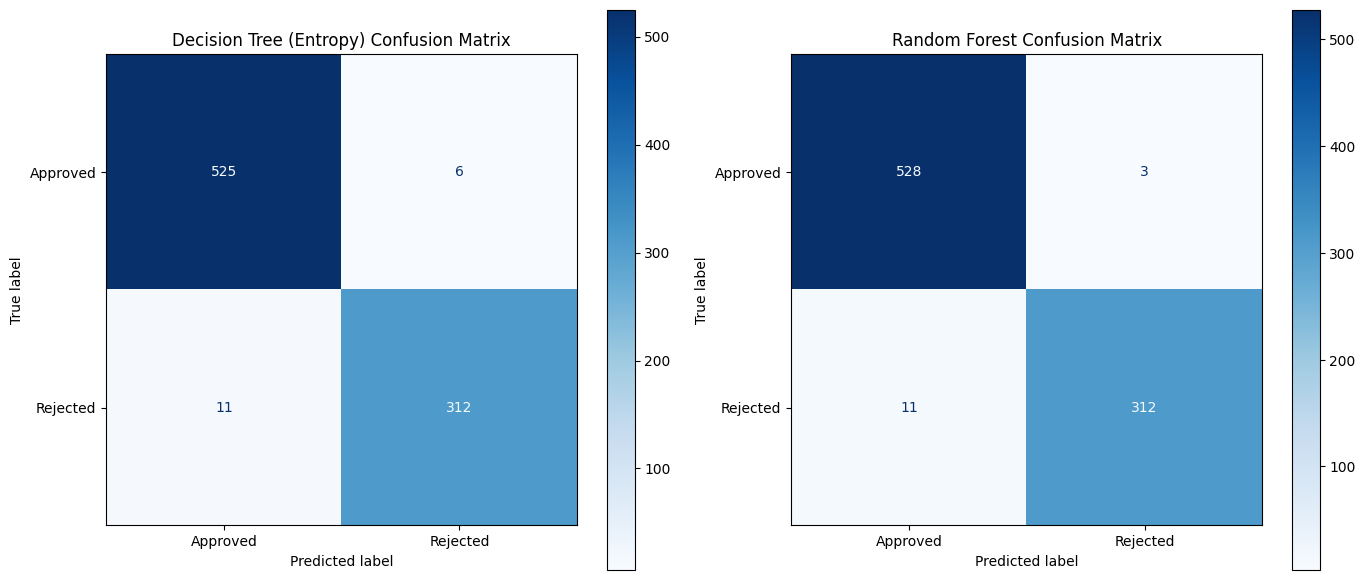

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot Confusion Matrix for Decision Tree (Entropy)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_dt_entropy = confusion_matrix(y_test, y_pred_entropy, labels=dt_entropy.classes_)
disp_dt_entropy = ConfusionMatrixDisplay(confusion_matrix=cm_dt_entropy, display_labels=['Approved', 'Rejected'])
disp_dt_entropy.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree (Entropy) Confusion Matrix')

# Plot Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Approved', 'Rejected'])
disp_rf.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

### 6. Conclusion

This project successfully developed and evaluated machine learning models for credit risk assessment, a critical challenge for financial institutions. We implemented and compared Decision Tree classifiers (using Gini impurity and Entropy) and a Random Forest classifier to categorize loan applicants into risk profiles.

**Key Findings:**

*   **Model Performance:** The Random Forest Classifier emerged as the best-performing model, achieving an accuracy of **0.9836**. It slightly outperformed the Decision Tree Classifier with Entropy (accuracy: 0.9801) and significantly surpassed the Decision Tree Classifier with Gini impurity (accuracy: 0.9719).
*   **Minimizing False Rejections:** The Random Forest model demonstrated superior capability in reducing false positives (incorrectly rejecting creditworthy applicants). It had only 3 false rejections compared to 6 for the Decision Tree (Entropy), which is crucial for minimizing missed business opportunities.
*   **Managing False Approvals:** Both the Random Forest and Decision Tree (Entropy) models performed similarly in terms of false negatives (incorrectly approving high-risk applicants), with 11 instances each. Minimizing these false approvals is vital to prevent financial losses from defaults.
*   **Feature Importance:** The **CIBIL Score** was identified as the most significant predictor of loan status by the Random Forest model, accounting for approximately 80% of the feature importance. This highlights its central role in credit risk assessment, followed by `loan_term`, `loan_amount`, and `income_annum`.

**Business Impact:**

The Random Forest model provides a robust decision support system that can significantly enhance the accuracy of loan approval decisions. By minimizing false rejections, it helps financial institutions capitalize on legitimate lending opportunities, while its overall high accuracy contributes to reduced financial losses from defaults. The insights into feature importance can also guide policy decisions and further refinement of credit assessment criteria. This system offers a reliable, data-driven approach to optimize loan portfolio management and mitigate risks effectively.

### 6. Deployment with Streamlit

To make our trained Random Forest model accessible for practical use, we can deploy it as a simple web application using Streamlit. This allows users to input new data and get real-time loan approval predictions. First, we need to save our trained model.

In [13]:
import joblib

# Define a filename for the model
model_filename = 'random_forest_loan_approval_model.joblib'

# Save the trained Random Forest model to a file
joblib.dump(rf_model, model_filename)

print(f"Random Forest model saved to {model_filename}")

Random Forest model saved to random_forest_loan_approval_model.joblib


Now, we will create a `streamlit_app.py` file. This file will contain the Streamlit code for our web application. The app will load the saved model and allow users to input features to get a loan approval prediction.

In [14]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained model
model = joblib.load('random_forest_loan_approval_model.joblib')

st.set_page_config(page_title="Loan Approval Predictor", layout="centered")

st.title("🏦 Loan Approval Predictor")
st.markdown("--- Say goodbye to manual appraisals and hello to efficiency! ---")

st.write("Enter the applicant's details below to predict their loan approval status.")

# Input features (based on X_train.columns)
no_of_dependents = st.slider('Number of Dependents', 0, 5, 2)
education = st.selectbox('Education', ['Graduate', 'Not Graduate'], format_func=lambda x: {'Graduate': 'Graduate', 'Not Graduate': 'Not Graduate'}[x])
self_employed = st.selectbox('Self Employed', ['Yes', 'No'], format_func=lambda x: {'Yes': 'Yes', 'No': 'No'}[x])
income_annum = st.number_input('Annual Income (in Lakhs)', min_value=1.0, max_value=100.0, value=50.0, step=0.1) * 100000 # Convert to actual value
loan_amount = st.number_input('Loan Amount (in Lakhs)', min_value=1.0, max_value=500.0, value=150.0, step=0.1) * 100000 # Convert to actual value
loan_term = st.slider('Loan Term (in years)', 1, 30, 10)
cibil_score = st.slider('CIBIL Score', 300, 900, 750)
residential_assets_value = st.number_input('Residential Assets Value (in Lakhs)', min_value=0.0, max_value=1000.0, value=20.0, step=0.1) * 100000
commercial_assets_value = st.number_input('Commercial Assets Value (in Lakhs)', min_value=0.0, max_value=1000.0, value=10.0, step=0.1) * 100000
luxury_assets_value = st.number_input('Luxury Assets Value (in Lakhs)', min_value=0.0, max_value=1000.0, value=50.0, step=0.1) * 100000
bank_asset_value = st.number_input('Bank Asset Value (in Lakhs)', min_value=0.0, max_value=1000.0, value=15.0, step=0.1) * 100000

# Encode categorical features
education_encoded = 0 if education == 'Graduate' else 1 # Assuming 0 for Graduate, 1 for Not Graduate from LabelEncoder
self_employed_encoded = 1 if self_employed == 'Yes' else 0 # Assuming 1 for Yes, 0 for No from LabelEncoder

# Create a DataFrame for prediction
input_data = pd.DataFrame([[no_of_dependents, education_encoded, self_employed_encoded, income_annum, loan_amount, loan_term, cibil_score, residential_assets_value, commercial_assets_value, luxury_assets_value, bank_asset_value]],
                           columns=['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'])

if st.button('Predict Loan Status'):
    prediction = model.predict(input_data)[0]
    if prediction == 0:
        st.success('Prediction: Loan Approved! 🎉')
    else:
        st.error('Prediction: Loan Rejected 🚫')

Writing streamlit_app.py


To run this Streamlit application:

1.  **Install Streamlit** (if you haven't already):
    ```bash
    pip install streamlit
    ```
2.  **Run the app** from your terminal in the directory where `streamlit_app.py` is saved:
    ```bash
    streamlit run streamlit_app.py
    ```

This will open the application in your web browser, allowing you to interact with the loan approval predictor.